In [64]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("../scripts/ga_benchmark_results.csv")
df["success_int"] = df["success"].astype(int)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   seed             1800 non-null   int64  
 1   puzzle           1800 non-null   str    
 2   n_gen            1800 non-null   int64  
 3   n_evals          1800 non-null   int64  
 4   success          1800 non-null   bool   
 5   time             1800 non-null   float64
 6   unique_f_in_pop  1800 non-null   int64  
 7   min_f            1800 non-null   int64  
 8   mean_f           1800 non-null   float64
 9   median_f         1800 non-null   float64
 10  max_f            1800 non-null   int64  
 11  greedier         1800 non-null   bool   
 12  exhaustive       1800 non-null   bool   
 13  strict           1800 non-null   bool   
 14  nudge            1800 non-null   bool   
 15  force_unique     1800 non-null   bool   
 16  variant          1800 non-null   str    
 17  variant_type     1600 non

In [4]:
summary = (
    df.groupby(["puzzle", "variant_type"])
    .agg(
        success_rate=("success", "mean"),
        success_count=("success_int", "sum"),
        # Only report mean for successful runs
        mean_gen_success=("n_gen", lambda x: x[df.loc[x.index, "success"]].mean()),
        max_gen_success=("n_gen", lambda x: x[df.loc[x.index, "success"]].max()),
        mean_best_f=("min_f", "mean"),
        pop_diversity=("unique_f_in_pop", "mean"),
        avg_time=("time", "mean"),
    )
    .reset_index()
)

In [69]:
summary

,puzzle,variant_type,success_rate,success_count,mean_gen_success,max_gen_success,mean_best_f,pop_diversity,avg_time
0,easy-11,modified,1.00,100,6.370000,10.0,0.00,12.01,0.615555
1,easy-11,paper,0.63,63,295.317460,1869.0,1.58,4.74,108.636034
2,hard-106,modified,0.24,24,516.083333,1679.0,1.52,10.17,210.854124
3,hard-106,paper,0.00,0,NaN,NaN,3.41,3.13,250.941423
4,hard-77,modified,0.92,92,227.576087,1840.0,0.16,10.90,47.031182
5,hard-77,paper,0.02,2,61.000000,82.0,2.85,3.22,244.448391
6,medium-27,modified,1.00,100,10.790000,25.0,0.00,11.47,1.149998
7,medium-27,paper,0.22,22,312.318182,1996.0,2.03,3.40,186.386603
8,medium-29,modified,1.00,100,30.280000,875.0,0.00,11.41,2.755536
9,medium-29,paper,0.15,15,318.200000,1751.0,2.26,3.35,208.910570


In [5]:
summary["success_rate"] = (summary["success_rate"] * 100).round(1).astype(str) + "%"
summary = summary.sort_values(["puzzle", "success_count"], ascending=[True, False])

print(
    summary[
        ["puzzle", "variant_type", "success_count", "success_rate", "mean_gen_success"]
    ]
)

       puzzle variant_type  success_count success_rate  mean_gen_success
0     easy-11     modified            100       100.0%          6.370000
1     easy-11        paper             63        63.0%        295.317460
2    hard-106     modified             24        24.0%        516.083333
3    hard-106        paper              0         0.0%               NaN
4     hard-77     modified             92        92.0%        227.576087
5     hard-77        paper              2         2.0%         61.000000
6   medium-27     modified            100       100.0%         10.790000
7   medium-27        paper             22        22.0%        312.318182
8   medium-29     modified            100       100.0%         30.280000
9   medium-29        paper             15        15.0%        318.200000
10        sd1     modified             33        33.0%        329.303030
11        sd1        paper              0         0.0%               NaN
12        sd2     modified             13        13

In [6]:
suppl_df = pd.read_csv("../scripts/ga_supplement_benchmark_results.csv")

In [7]:
suppl_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   seed             1900 non-null   int64  
 1   puzzle           1900 non-null   str    
 2   n_gen            1900 non-null   int64  
 3   n_evals          1900 non-null   int64  
 4   success          1900 non-null   bool   
 5   time             1900 non-null   float64
 6   unique_f_in_pop  1900 non-null   int64  
 7   min_f            1900 non-null   int64  
 8   mean_f           1900 non-null   float64
 9   median_f         1900 non-null   float64
 10  max_f            1900 non-null   int64  
 11  greedier         1900 non-null   bool   
 12  exhaustive       1900 non-null   bool   
 13  strict           1900 non-null   bool   
 14  nudge            1900 non-null   bool   
 15  force_unique     1900 non-null   bool   
 16  source           1900 non-null   str    
 17  difficulty       1900 non

In [8]:
websudoku_stats = (
    suppl_df[suppl_df["source"] == "websudoku"]
    .groupby("difficulty")
    .agg(
        success_rate=("success", "mean"),
        avg_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].mean()),
        std_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].std()),
        mean_min=("min_f", "mean"),
    )
    .reindex(["easy", "medium", "hard", "evil"])
)

In [9]:
websudoku_stats

,success_rate,avg_gens,std_gens,mean_min
difficulty,,,,
easy,1.000000,6.166667,1.653684,0.000000
medium,0.983333,29.315254,96.570120,0.033333
hard,0.760000,81.447368,127.955120,0.483333
evil,0.683333,162.336585,302.577342,0.633333


In [10]:
se_stats = (
    suppl_df[suppl_df["source"] == "sudoku_explainer"]
    .groupby("difficulty")
    .agg(
        success_rate=("success", "mean"),
        avg_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].mean()),
        std_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].std()),
        max_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].max()),
        mean_min=("min_f", "mean"),
    )
    .reindex(["easy", "medium", "hard", "superior", "fiendish", "super", "advance"])
)

In [11]:
se_stats

,success_rate,avg_gens,std_gens,max_gens,mean_min
difficulty,,,,,
easy,0.87,89.103448,262.344485,1331,0.26
medium,0.77,157.441558,279.327317,1425,0.46
hard,0.87,77.712644,143.922937,704,0.27
superior,0.67,112.313433,172.833622,740,0.66
fiendish,0.69,179.231884,316.300497,1330,0.62
super,0.70,105.857143,240.409812,1107,0.60
advance,0.80,141.525000,219.433100,896,0.40


<Figure size 640x480 with 0 Axes>

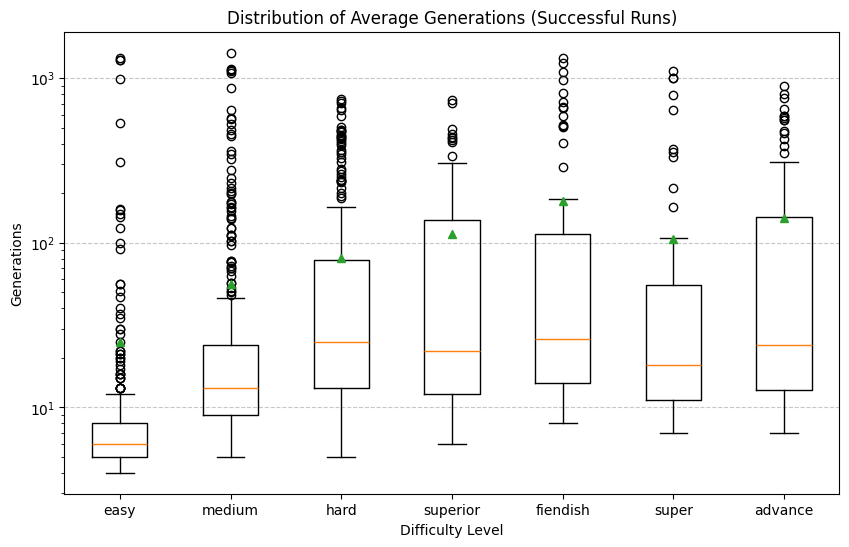

In [100]:
%matplotlib inline
plt.clf()
plt.figure(figsize=(10, 6))
success_df = suppl_df[suppl_df['success'] == True]

level_order = ['easy', 'medium', 'hard', 'superior', 'fiendish', 'super', 'advance']
plot_data = [success_df[success_df['difficulty'] == lvl]['n_gen'] for lvl in level_order]

plt.boxplot(plot_data, tick_labels=level_order, showmeans=True)
plt.title("Distribution of Average Generations (Successful Runs)")
plt.ylabel("Generations")
plt.xlabel("Difficulty Level")
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.draw()

In [15]:
se_df = suppl_df[suppl_df['source'] == 'sudoku_explainer'].copy()
table_v = se_df.groupby(['difficulty', 'puzzle']).agg(
    success_rate=('success', 'mean'),
    avg_gen=('n_gen', lambda x: x[se_df.loc[x.index, 'success']].mean())
).reset_index()
diff_order = {
    'easy': 0, 'medium': 1, 'hard': 2, 'superior': 3, 'fiendish': 4, 'super': 5, 'advance': 6
}
table_v['order'] = table_v['difficulty'].map(diff_order)
table_v = table_v.sort_values(['order', 'puzzle']).drop(columns=['order'])
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(table_v)

,difficulty,puzzle,success_rate,avg_gen
10,easy,easy-no.1,1.0,7.300000
11,easy,easy-no.10,0.7,96.714286
12,easy,easy-no.2,1.0,15.500000
13,easy,easy-no.3,1.0,7.200000
14,easy,easy-no.4,1.0,10.900000
15,easy,easy-no.5,0.9,173.111111
16,easy,easy-no.6,0.6,298.666667
17,easy,easy-no.7,1.0,4.800000
18,easy,easy-no.8,0.5,333.600000
19,easy,easy-no.9,1.0,160.000000


In [89]:
# puzzle_audit = suppl_df[suppl_df['difficulty'].isin(['easy', 'medium'])].groupby(['difficulty', 'puzzle']).agg(
puzzle_audit = (
    suppl_df.groupby(["difficulty", "puzzle"])
    .agg(
        success_count=("success", "sum"),
        min_f_reached=("min_f", "min"),
        avg_f_reached=("min_f", "mean"),
    )
    .reset_index()
)

failed_puzzles = puzzle_audit[puzzle_audit["success_count"] < 10]
display(failed_puzzles)

,difficulty,puzzle,success_count,min_f_reached,avg_f_reached
0,advance,advance-no.1,6,0,0.8
1,advance,advance-no.10,8,0,0.4
2,advance,advance-no.2,9,0,0.2
4,advance,advance-no.4,5,0,1.0
5,advance,advance-no.5,7,0,0.6
...,...,...,...,...,...
182,superior,superior-no.2,8,0,0.4
183,superior,superior-no.3,4,0,1.2
184,superior,superior-no.4,4,0,1.2
185,superior,superior-no.5,4,0,1.2


In [ ]:
# rewrite_df = pd.read_csv("../scripts/ga_supplement_benchmark_results.csv")
# targets = [
#     "easy-no.10",
#     "easy-no.5",
#     "easy-no.6",
#     "easy-no.8",
#     "easy-no.9",
#     "1195098050",
#     "1490459242",
#     "2152823431",
#     "2372227873",
#     "medium-no.1",
#     "medium-no.2",
#     "medium-no.3",
#     "medium-no.4",
#     "medium-no.5",
#     "medium-no.6",
#     "medium-no.8",
# ]
# df_cleaned = rewrite_df[~rewrite_df["puzzle"].isin(targets)]
# df_cleaned.to_csv("../scripts/ga_supplement_benchmark_results.csv", index=False)